## Time Series Modeling

### 1. Inspect dataframe

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load data and set day as frequency
df = pd.read_parquet("cleaned_data.parquet")
df = df.asfreq("D")

In [4]:
#Create new dataframe and sort
ts_df = df.copy()
ts_df.sort_index()

#Check the size and shape
print(ts_df.head(2))
print(ts_df.tail(2))

print("Start date:", ts_df.index.min())
print("End date:", ts_df.index.max())
print("Number of rows:", len(ts_df))

                     temp_mean  temp_max  temp_min  soil_temp_5cm  \
reference_timestamp                                                 
1990-01-01                -6.1       0.0     -10.0           -0.2   
1990-01-02                -6.5      -1.3     -10.5           -0.3   

                     rel_humidity  tot_precipitation  windspeed  \
reference_timestamp                                               
1990-01-01                   55.4                0.0        0.4   
1990-01-02                   57.8                0.0        0.9   

                     glob_radiation  sunshine_duration  erle_pollen  \
reference_timestamp                                                   
1990-01-01                     74.0              375.0          0.0   
1990-01-02                     74.0              376.0          0.0   

                     birke_pollen  hasel_pollen  buche_pollen  \
reference_timestamp                                             
1990-01-01                    0.0      

Our Time Series starts in 1990-01-01 and ends in 2025-12-31.

In [5]:
#Check NA and NAN
print(ts_df.isna().sum())

temp_mean                 0
temp_max                  0
temp_min                  0
soil_temp_5cm             0
rel_humidity              0
tot_precipitation         0
windspeed                 0
glob_radiation            0
sunshine_duration       199
erle_pollen               0
birke_pollen              0
hasel_pollen              0
buche_pollen              0
gemeine_esche_pollen      0
eiche_pollen              0
graeser_pollen            0
dtype: int64


We will remove sunshine_duration since it has missing values and we will also only focus on a subset of pollen variables. Namely, Erle, Gräser, Hasel and Birke

In [6]:
#Drop not relevant columns
ts_df = ts_df.drop(columns=["sunshine_duration", "buche_pollen", "gemeine_esche_pollen", "eiche_pollen"])
print(ts_df.columns)

Index(['temp_mean', 'temp_max', 'temp_min', 'soil_temp_5cm', 'rel_humidity',
       'tot_precipitation', 'windspeed', 'glob_radiation', 'erle_pollen',
       'birke_pollen', 'hasel_pollen', 'graeser_pollen'],
      dtype='str')


In [7]:
#Create df for environmental and pollen variables
environ_df = ts_df[['temp_mean', 'temp_max', 'temp_min', 'soil_temp_5cm', 'rel_humidity', 'tot_precipitation', 'windspeed', 'glob_radiation']]
pollen_df = ts_df[['erle_pollen', 'birke_pollen', 'hasel_pollen', 'graeser_pollen']]

### 2. Plot and Analyze the Structure

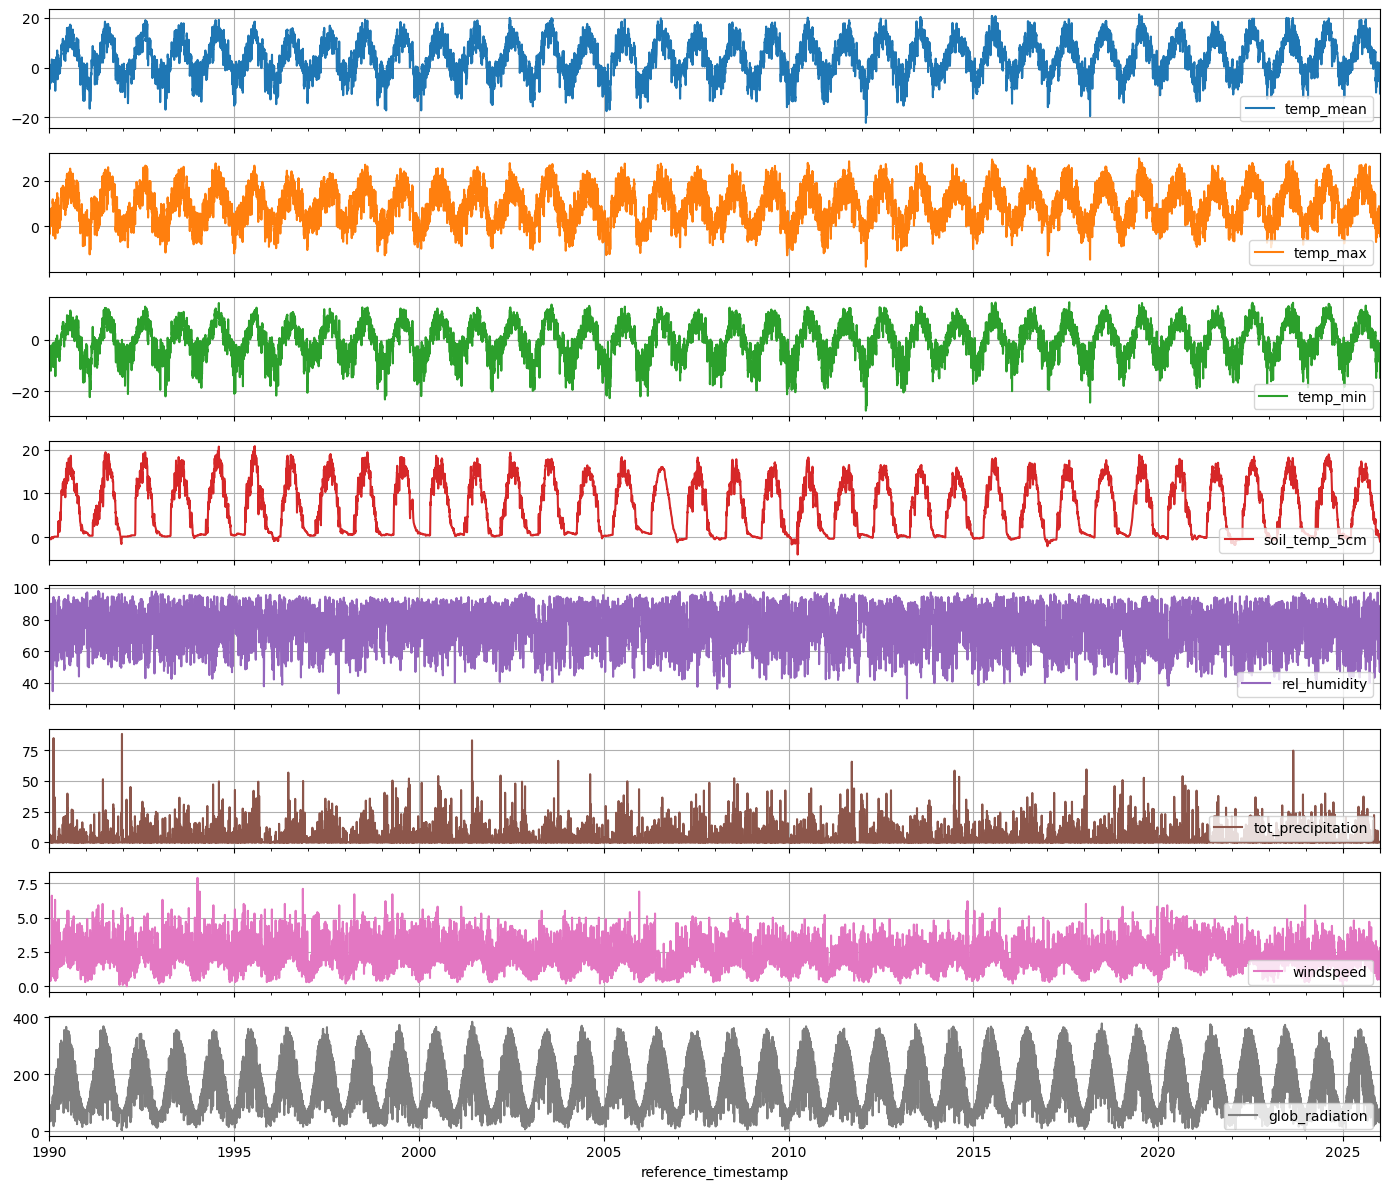

In [8]:
#Plot environmental variables
axes = environ_df.plot(subplots=True, figsize=(14, 12), sharex=True)

for ax in axes:
    ax.legend(loc="lower right")
    ax.grid(True)

plt.tight_layout()
plt.show()

temp_mean: no observable trend, annual periodicity, some slight outliers\
temp_max: no observable trend, annual periodicity, some slight outliers\
temp_min: no observable trend, annual periodicity, some slight outliers\
soil_temp_5cm: no oservable trend, annual periodicity, one outlier in 2010\
rel_humidity: no observable trend, slight to no periodicty, very noisy\
tot_percipitation: very slight decreas trend, annual periodicity, some outliers\
windspeed: very slight decreas trend, annual periodicity, few outliers\
glob_radiation: no observable trend, annual periodicity, no outliers

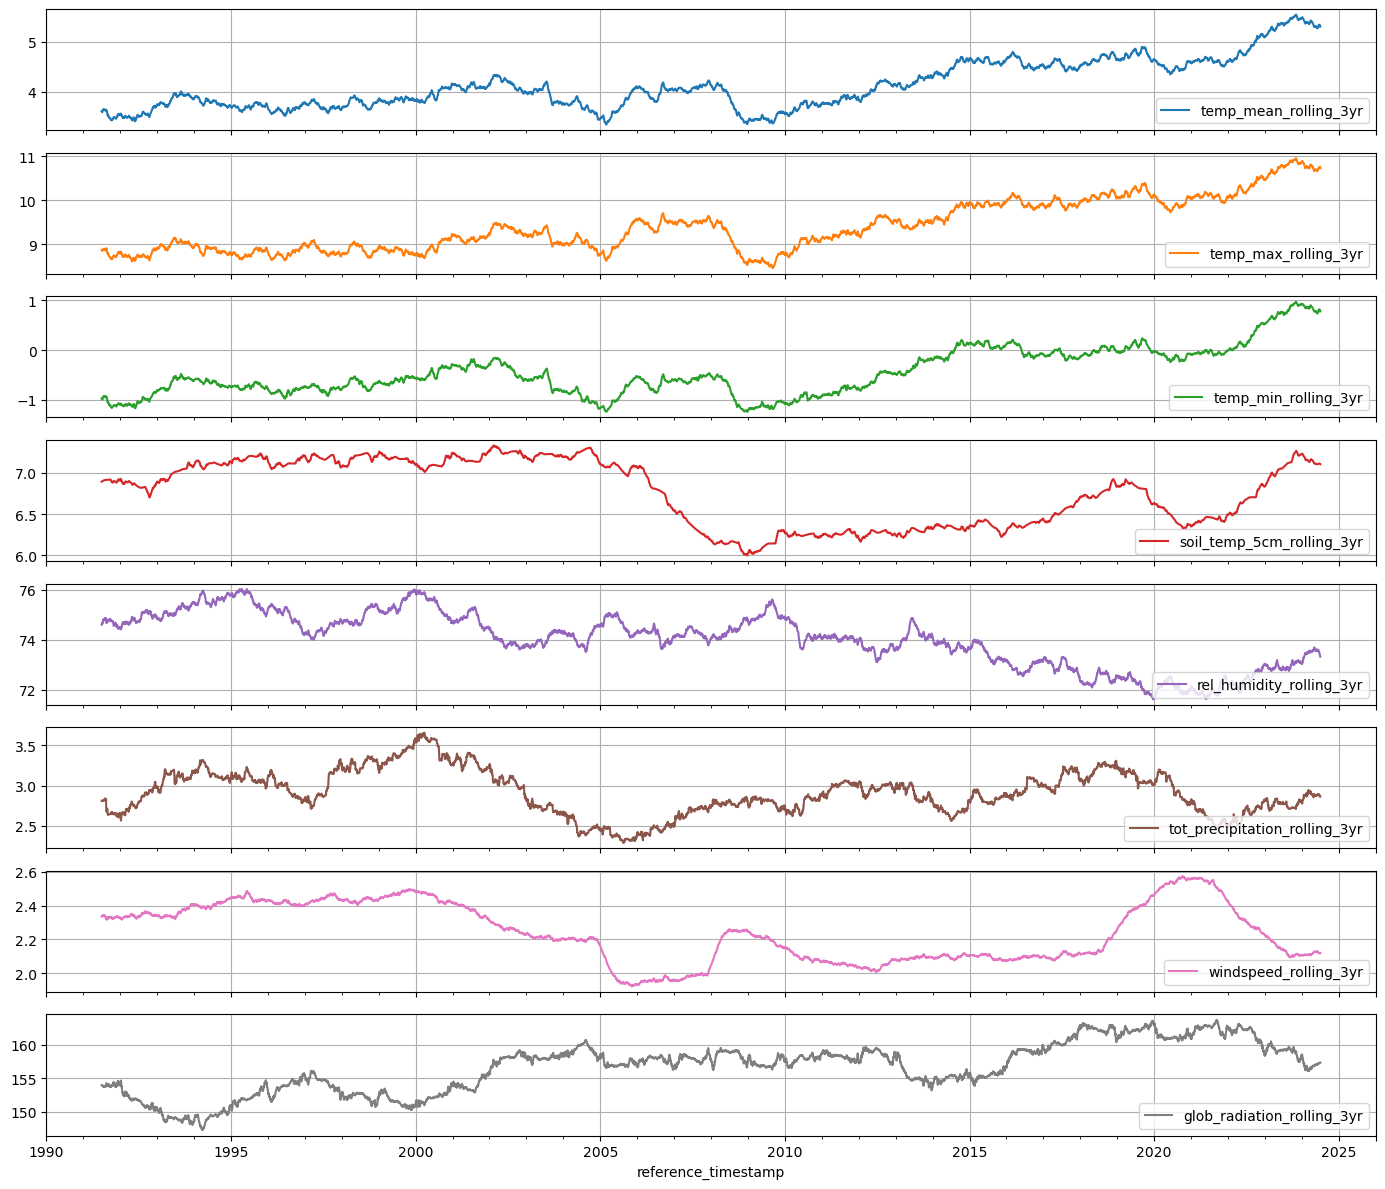

In [9]:
#Plot smoothed environmental variables
environ_rolling_df = pd.DataFrame(index=environ_df.index)
for col in environ_df.columns:
    environ_rolling_df[f"{col}_rolling_3yr"] = environ_df[col].rolling(3*365, center=True).mean()

axes = environ_rolling_df.plot(subplots=True, figsize=(14, 12), sharex=True)
for ax in axes:
    ax.legend(loc="lower right")
    ax.grid(True)

plt.tight_layout()
plt.show()

temp_mean: We see an increase of about 2 degrees\
temp_min: same\
temp_max: same\
soil_temp_5cm: Drops arround 2008 but recover starts around 2018\
rel_humidity: Decreased\
tot_percipitation: stays around 3 
windspeed: shows low plateau abetween 2007 and 2009, increase around 2020 to 2025
glob_radiation: Medium increase

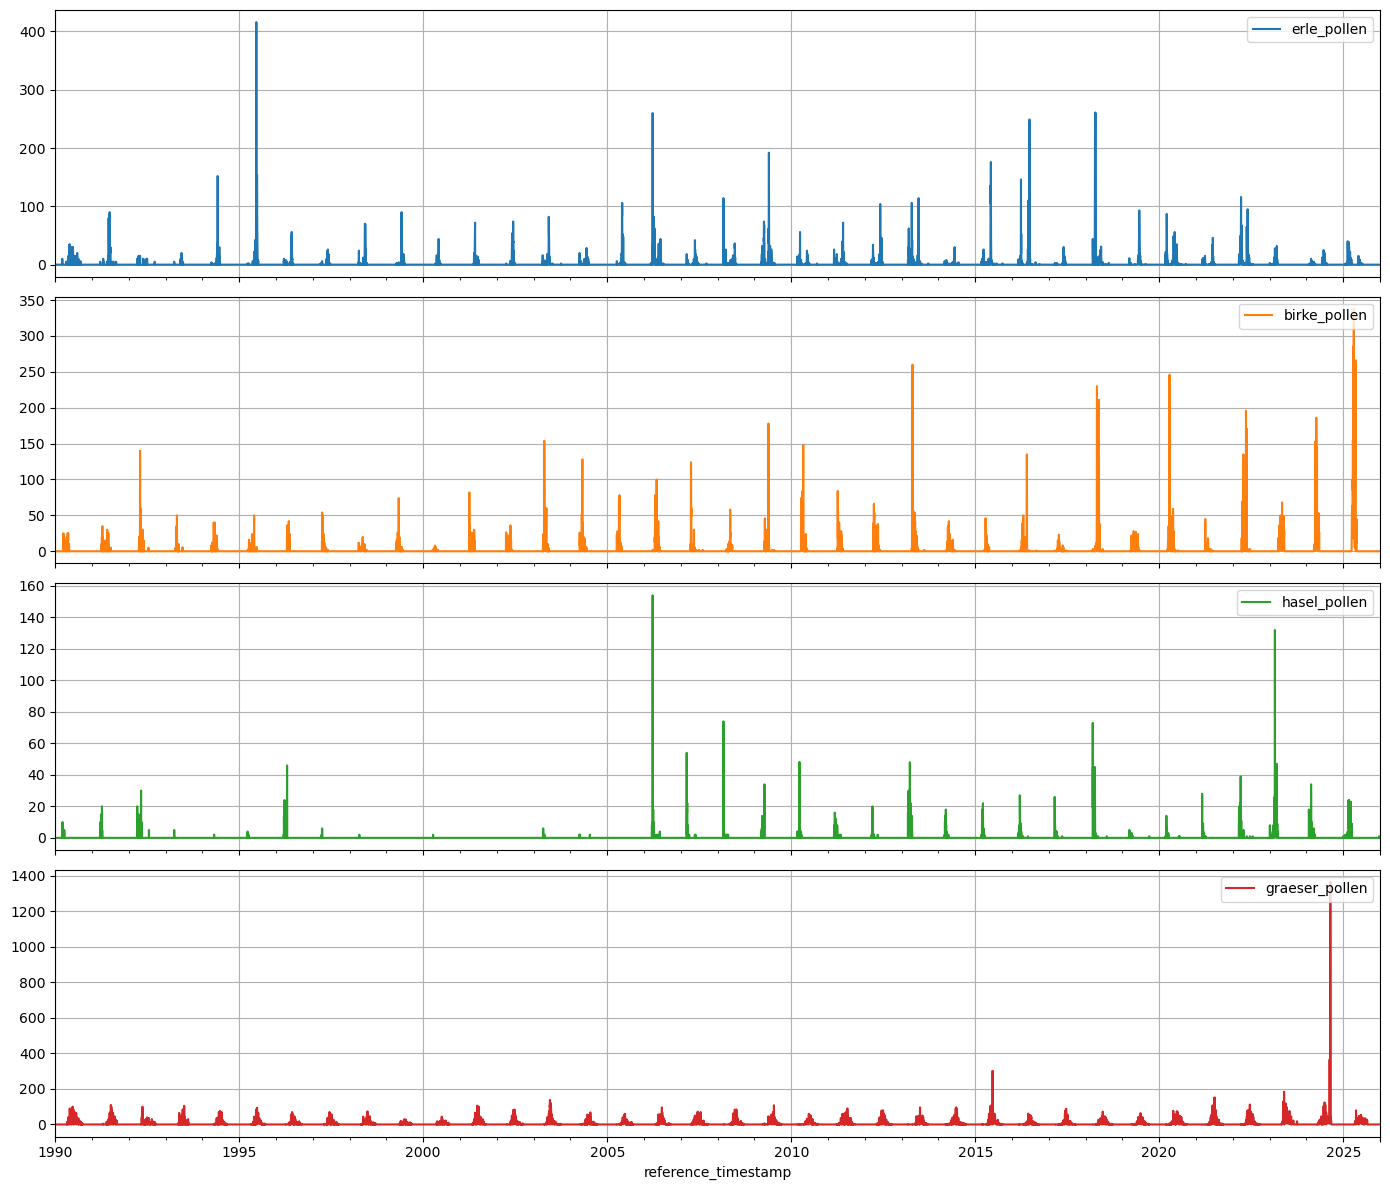

In [10]:
#Plot pollen variables
axes = pollen_df.plot(subplots=True, figsize=(14, 12), sharex=True)

for ax in axes:
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()

erle_pollen: no trend, annual periodicity, spiky\
birke_pollen: seems to increase, annual periodicity, spiky\
hasel_pollen: no trend, mostly annual periodicity, not really peresent between 1997 and 2005, spiky\
graser_pollen:slight increase, annual periodicity, smoother, slight outlier in 2015 and 2024

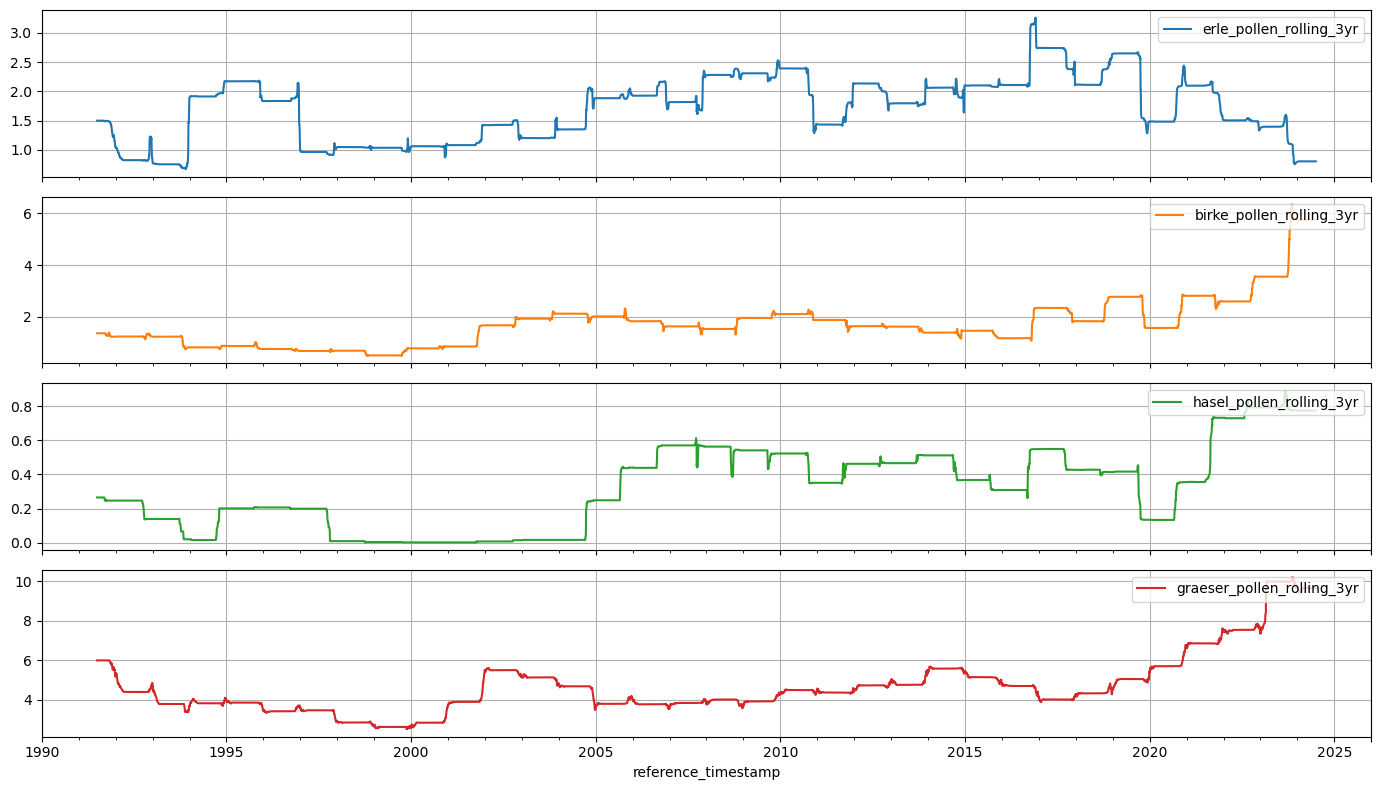

In [11]:
#Plot smoothed pollen variables
pollen_rolling_df = pd.DataFrame(index=pollen_df.index)
for col in pollen_df.columns:
    pollen_rolling_df[f"{col}_rolling_3yr"] = pollen_df[col].rolling(3*365, center=True).mean()

axes = pollen_rolling_df.plot(subplots=True, figsize=(14, 8), sharex=True)

for ax in axes:
    ax.legend(loc="upper right")
    ax.grid(True)

plt.tight_layout()
plt.show()

erle_pollen: Stays approx the same\
birke_pollen: Shows increase in recent years (2020 onwards)\
hasel_pollen: Sharp incrase after 2005\
graeser_pollen: Also increased after 2020

We will now use a Mann-Kendall trend test to determine if we have statistical evidence for an increase or decrease.

In [12]:
#Mann Kendall to test for increase/decrease
!pip install pymannkendall
import pymannkendall as mk

print(f"{'variable':<18} {'p-value':>12}  {'trend':<12} {'slope':>14}")
print("-" * 60)

for col in environ_df.columns:
    res = mk.original_test(environ_df[col])
    print(f"{col:<18} {res.p:>12.5f}  {str(res.trend):<12} {res.slope:>14.8f}")

  Using cached pymannkendall-1.4.3-py3-none-any.whl.metadata (14 kB)
Using cached pymannkendall-1.4.3-py3-none-any.whl (12 kB)
variable                p-value  trend                 slope
------------------------------------------------------------
temp_mean               0.00000  increasing       0.00012422
temp_max                0.00000  increasing       0.00015528
temp_min                0.00000  increasing       0.00011352
soil_temp_5cm           0.00000  decreasing      -0.00004091
rel_humidity            0.00000  decreasing      -0.00019289
tot_precipitation       0.95412  no trend         0.00000000
windspeed               0.00000  decreasing      -0.00001302
glob_radiation          0.00585  increasing       0.00053648


All temps have increased according to the test. However, soiltemp has decreased, so did relative humidity. Total percipitation did not show trend. Windspeed is trending downwards, while global radiation is increasing. However, the slopes are quite small for all variables.

In [13]:
#Mann Kendall to test for increase/decrease
print(f"{'variable':<18} {'p-value':>12}  {'trend':<12} {'slope':>14}")
print("-" * 60)
for col in pollen_df.columns:
    res = mk.original_test(pollen_df[col])
    print(f"{col:<18} {res.p:>12.5f}  {str(res.trend):<12} {res.slope:>14.8f}")

variable                p-value  trend                 slope
------------------------------------------------------------
erle_pollen             0.00000  increasing       0.00000000
birke_pollen            0.00000  increasing       0.00000000
hasel_pollen            0.00000  increasing       0.00000000
graeser_pollen          0.00000  increasing       0.00000000


All Pollen types are increasing according to the test, however the slope is extremely small

## Trend, Seasonal and Residual Decomposition

Again, we will only focus on a subsets of variables here. (Others are highly correlated, like temp_mean and temp_max)

In [14]:
#Variable Selection
sarima_df = ts_df[["temp_mean", "soil_temp_5cm", "tot_precipitation", "glob_radiation", 
                   "erle_pollen", "birke_pollen", "hasel_pollen", "graeser_pollen"]]

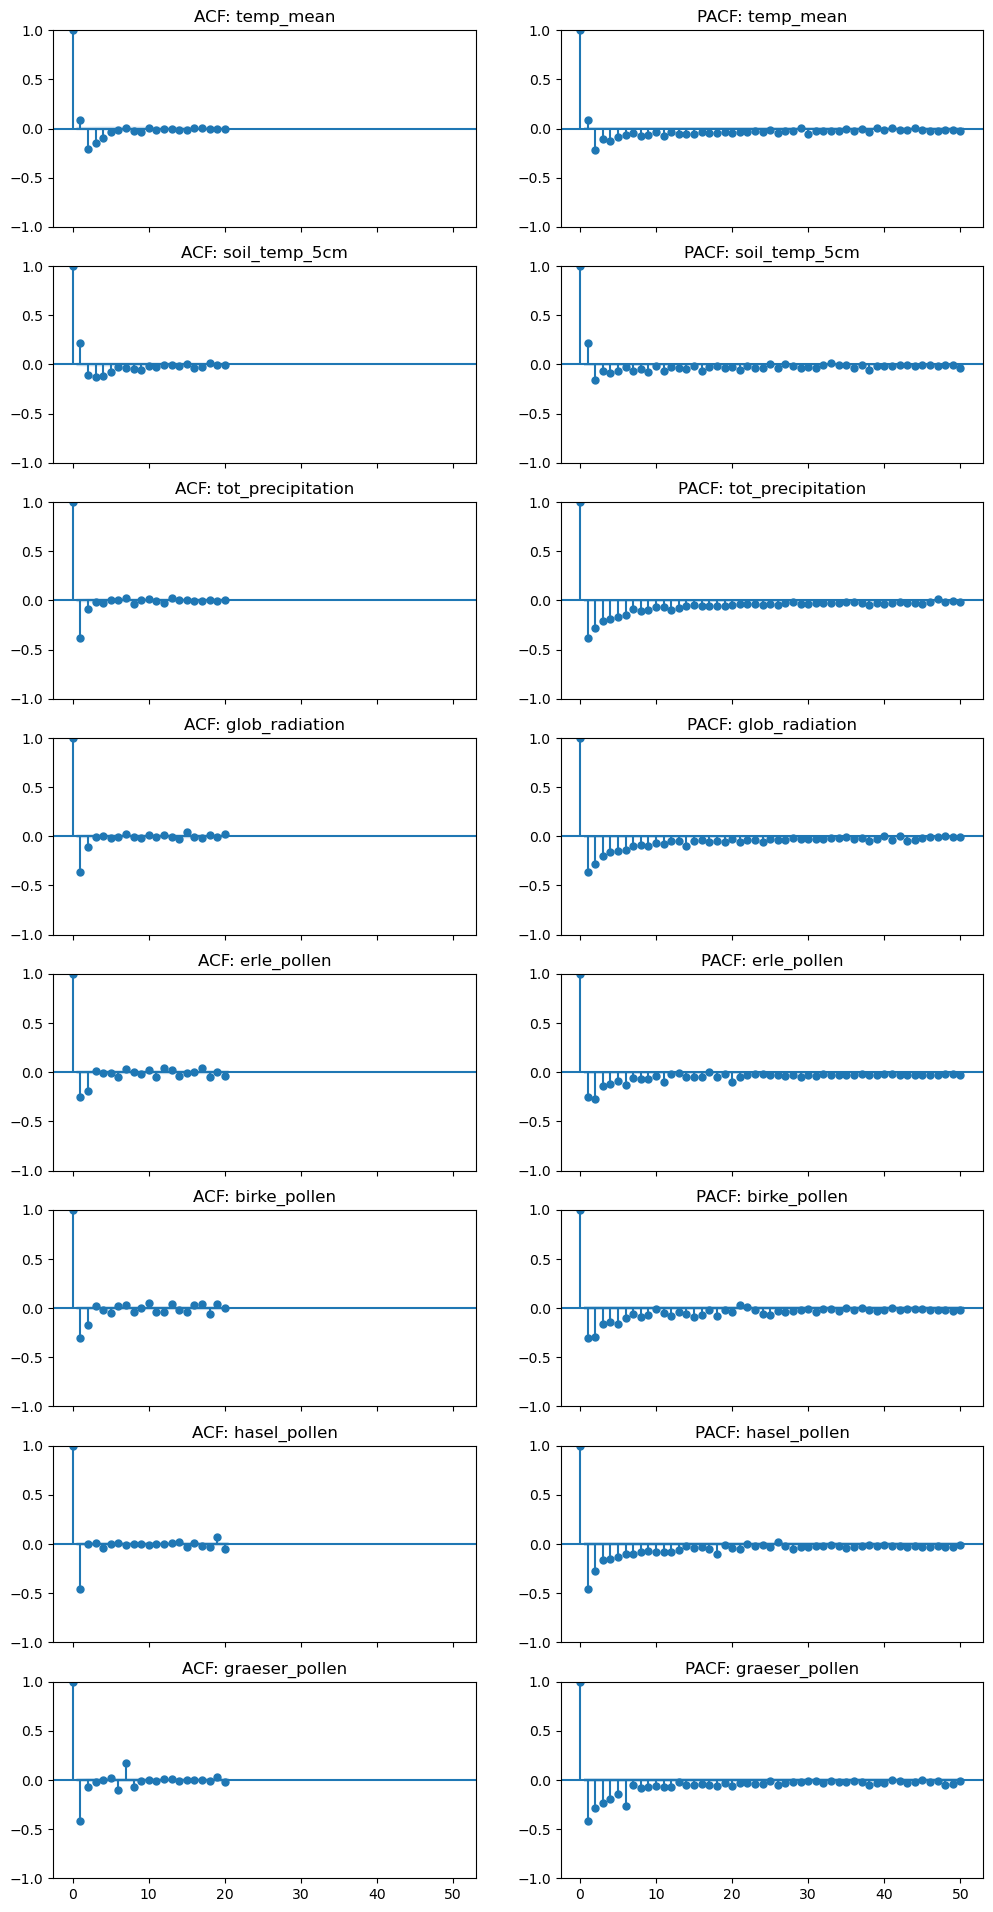

In [15]:
#Plot ACF and PACF for differenced timeseries
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

nrow = len(sarima_df.columns)
ncol = 2

fig, axes = plt.subplots(nrow, ncol, sharex=True, figsize=(12, 3*nrow))

for i, col in enumerate(sarima_df.columns):
    y_diff = sarima_df[col].diff().diff(365).dropna()

    plot_acf(y_diff, lags=20, ax=axes[i][0])
    axes[i][0].set_title(f"ACF: {col}")

    plot_pacf(y_diff, lags=50, ax=axes[i][1], method="ywm")
    axes[i][1].set_title(f"PACF: {col}")


### Temp_mean ARIMA model

In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

#difference time series
y = sarima_df["temp_mean"].diff().diff(365).dropna()
#fit model
model = SARIMAX(y, order = (2, 0, 2))
res = model.fit()

In [50]:
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:              temp_mean   No. Observations:                12783
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -32656.945
Date:                Mon, 20 Apr 2026   AIC                          65323.891
Time:                        16:23:22   BIC                          65361.170
Sample:                    01-02-1991   HQIC                         65336.357
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6190      0.034     18.451      0.000       0.553       0.685
ar.L2          0.0586      0.028      2.078      0.038       0.003       0.114
ma.L1         -0.6330      0.034    -18.561      0.0

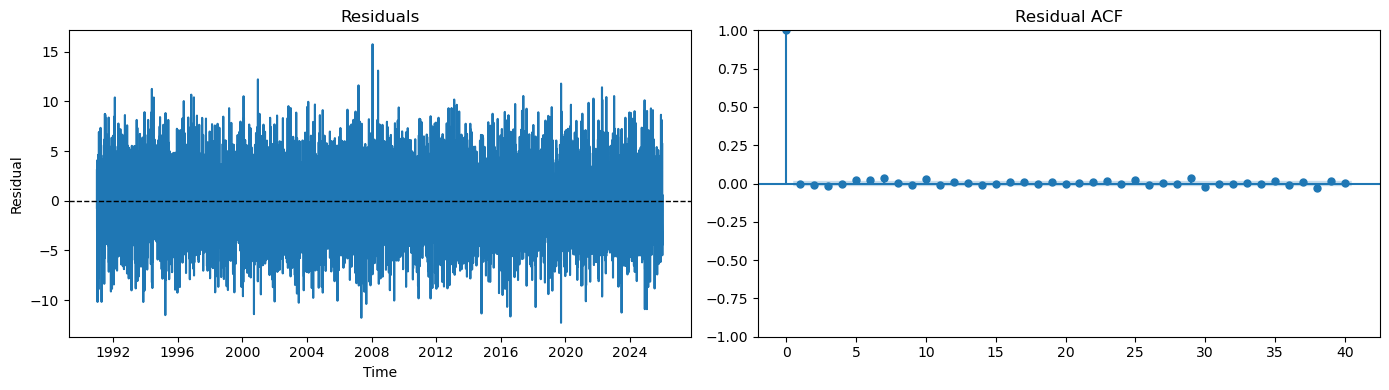

       lb_stat     lb_pvalue
10   46.144677  1.350219e-06
20   54.412624  5.023523e-05
30   86.742081  2.029880e-07
40  104.123689  1.285049e-07


In [52]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = res.resid.dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Residuals over time
axes[0].plot(residuals)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Residuals")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Residual")
# Residual autocorrelation
plot_acf(residuals, lags=40, ax=axes[1])
axes[1].set_title("Residual ACF")
plt.tight_layout()
plt.show()
print(acorr_ljungbox(residuals, lags=[10, 20, 30, 40], return_df=True))

- All Perdictors are statistically significant
- Ljung Box for 1 Lag (Q) is 0.0, hence there is no 1 Lag Correlation (great)
- Residual Plot looks like white noise around 0
- ACF stays low for all lags ≥ 1
- Ljung box for more lags howevery show that there is some correlation left (Can come from large nb of observations)
- Overall, good model, explains temporal dependce quite well

### Soil Temp 5cm

In [53]:
y = sarima_df["soil_temp_5cm"].diff().diff(365).dropna()
model = SARIMAX(y, order = (2, 0, 2))
res = model.fit()

In [54]:
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:          soil_temp_5cm   No. Observations:                12783
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -16164.271
Date:                Mon, 20 Apr 2026   AIC                          32338.541
Time:                        16:24:21   BIC                          32375.821
Sample:                    01-02-1991   HQIC                         32351.008
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9140      0.021     43.983      0.000       0.873       0.955
ar.L2         -0.0602      0.019     -3.119      0.002      -0.098      -0.022
ma.L1         -0.7274      0.021    -34.037      0.0

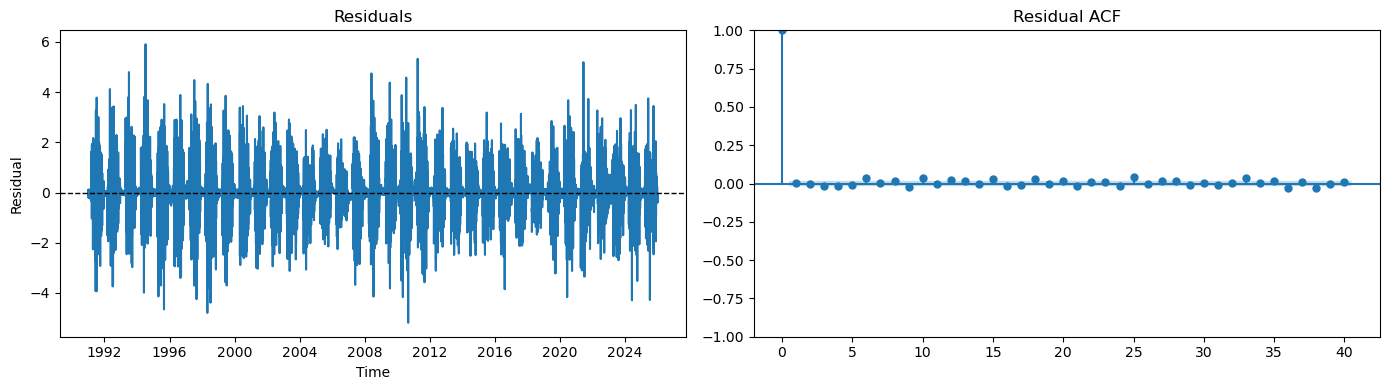

       lb_stat     lb_pvalue
10   53.164031  6.941490e-08
20   90.916590  5.123120e-11
30  137.384641  1.098123e-15
40  188.726497  3.555989e-21


In [55]:
residuals = res.resid.dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Residuals over time
axes[0].plot(residuals)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Residuals")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Residual")
# Residual autocorrelation
plot_acf(residuals, lags=40, ax=axes[1])
axes[1].set_title("Residual ACF")
plt.tight_layout()
plt.show()
print(acorr_ljungbox(residuals, lags=[10, 20, 30, 40], return_df=True))

- Again, all predictors are statistically significant
- 1 Lag Ljung Box looks good again
- Residual plot is bad, we see that the model did not capture some seasonality, differencing is not enough
- Autocorrelation plot is fine
- Box Ljung for other lags show that residuals are not white noise

We will try an STL decomposition approach

In [60]:
from statsmodels.tsa.seasonal import STL

stl = STL(sarima_df["soil_temp_5cm"], period=365)
decomp = stl.fit()
y = decomp.resid

model = SARIMAX(y, order=(2, 0, 2))
res = model.fit()

/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**There is a convergence warning when using STL. Probably not working correctly**

In [61]:
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                  resid   No. Observations:                13149
Model:               SARIMAX(2, 0, 2)   Log Likelihood               -9182.605
Date:                Mon, 20 Apr 2026   AIC                          18375.210
Time:                        16:30:05   BIC                          18412.631
Sample:                    01-01-1990   HQIC                         18387.706
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0119      0.044     -0.271      0.786      -0.098       0.074
ar.L2          0.7140      0.038     18.751      0.000       0.639       0.789
ma.L1          1.1923      0.044     27.394      0.0

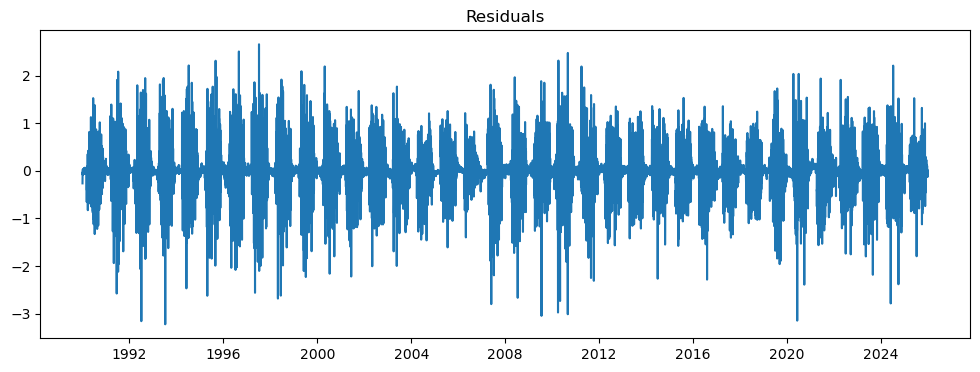

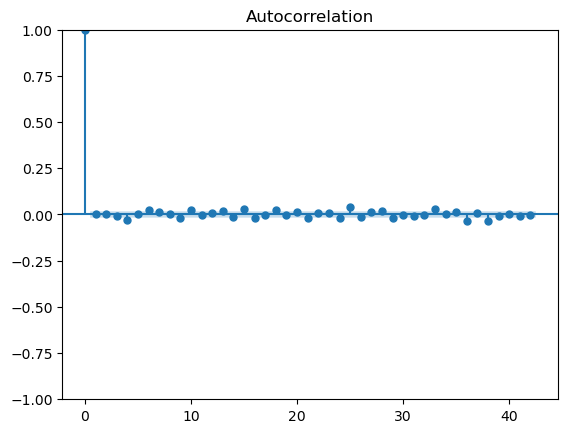

       lb_stat     lb_pvalue
10   35.836370  8.980334e-05
20   74.090171  3.860732e-08
30  119.914806  1.054358e-12
40  164.516146  4.910827e-17


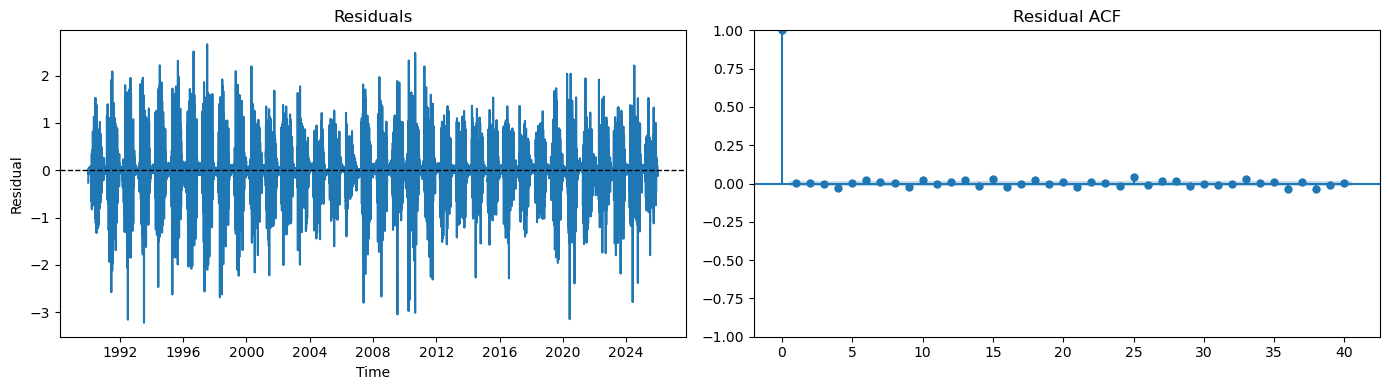

       lb_stat     lb_pvalue
10   35.836370  8.980334e-05
20   74.090171  3.860732e-08
30  119.914806  1.054358e-12
40  164.516146  4.910827e-17


In [62]:
residuals = res.resid.dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Residuals over time
axes[0].plot(residuals)
axes[0].axhline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_title("Residuals")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Residual")
# Residual autocorrelation
plot_acf(residuals, lags=40, ax=axes[1])
axes[1].set_title("Residual ACF")
plt.tight_layout()
plt.show()
print(acorr_ljungbox(residuals, lags=[10, 20, 30, 40], return_df=True))

- One LAg BoxLjung slightly increased
- Residuals still show seasonal dependence
- Autocorrelation is fine
- Box-Ljung for other lags has increased a bit which is better

ARMA-type modelling after standard processing does not fully capture the temporal structure.
This suggest the usage of a more complex model ? 

### Lets do the same thing for percipitation

In [33]:
y = sarima_df["tot_precipitation"].diff().diff(365).dropna()

model = SARIMAX(y, order=(2, 0, 2))
res = model.fit()

In [34]:
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:      tot_precipitation   No. Observations:                12783
Model:               SARIMAX(2, 0, 2)   Log Likelihood              -46013.041
Date:                Mon, 20 Apr 2026   AIC                          92036.083
Time:                        16:12:19   BIC                          92073.362
Sample:                    01-02-1991   HQIC                         92048.549
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7060      0.055    -12.850      0.000      -0.814      -0.598
ar.L2          0.2014      0.016     12.443      0.000       0.170       0.233
ma.L1         -0.0681      0.056     -1.226      0.2

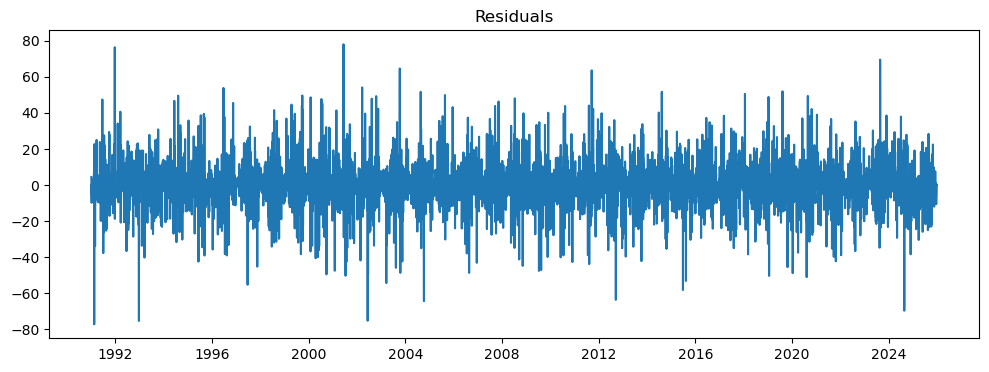

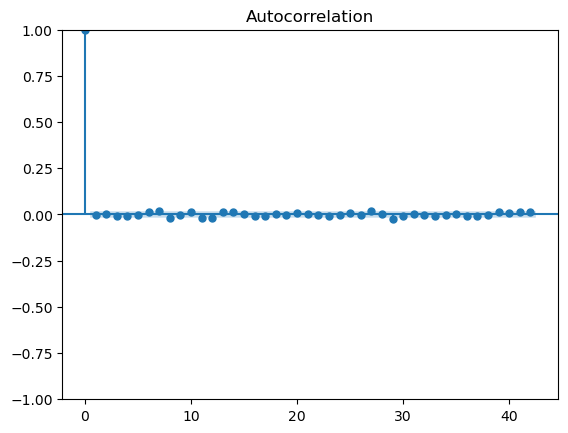

      lb_stat  lb_pvalue
10  14.461689   0.152955
20  28.847122   0.090813
30  41.524990   0.078545
40  48.986745   0.155920


In [35]:
residuals = res.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

plot_acf(residuals)
plt.show()
print(acorr_ljungbox(res.resid.dropna(), lags=[10,20,30,40], return_df=True))

- After differencing, the ARMA(2,2) model provides a good fit for the total precipitation series.
- Residual plot still shows some non white noise behaviour.
- The residual Ljung Box tests at lags 10, 20, 30, and 40 are not significant.
- Therefore, the model captures the main temporal dependence structure of the differenced series well.
- Most model coefficients are significant, although the MA(1) term is not significant, suggesting that a simpler model could also be considered.
- This is not unusual for precipitation data, which often show heavy tails and extreme values.
- Overall, the model appears adequate for describing the differenced precipitation series.